In [16]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from gensim.models import word2vec
from tensorflow.keras import preprocessing
from pyvi import ViTokenizer
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from tensorflow.keras.preprocessing import sequence

sys.path.append(os.path.abspath('../function'))
from embedding import PatchEmbedding, MeanVectorizer
import cleandt

## Import and normalize data

In [3]:
# Đọc dữ liệu
news = pd.read_csv('../data/data_processed/train_no_label.csv') 
print(news.shape)
print(news.info())
print(news.head())


(8898, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8898 entries, 0 to 8897
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   comment    8898 non-null   object
 1   n_star     8898 non-null   int64 
 2   date_time  8898 non-null   object
dtypes: int64(1), object(2)
memory usage: 208.7+ KB
None
                                             comment  n_star   date_time
0  pin kém còn miễn chê mua 832019 tình_trạng pin...       5  14/09/2019
1  sao gọi điện_thoại màn_hình chấm nhỏ nháy gần ...       3  17/08/2020
2  mọi người cập_nhật phần_mềm nó bớt tốn pin mìn...       3  29/02/2020
3  mới mua sài 1 tháng thấy pin trâu sài bao mượt...       5    4/6/2020
4  xài tốt mượt pin trâu bạn độ sáng đủ nhân_viên...       5  20/06/2019


In [4]:
# Kiểm tra và xử lý giá trị thiếu
print(news.isna().sum())
news.dropna(axis=0, inplace=True)
news.reset_index(inplace=True)
news.drop(columns=['index'], axis=1, inplace=True)

comment      0
n_star       0
date_time    0
dtype: int64


## Create word embedding model from Word2Vec

In [5]:
sequences = news['comment'].to_list()
input_gensim = []

for sen in sequences:
  input_gensim.append(sen.split())

In [49]:
# model = word2vec.Word2Vec(input_gensim, vector_size=128, window=5, min_count=0, workers=4, sg=1)
# model.save("../model/word2vec_no_label.model")

In [6]:
model = word2vec.Word2Vec.load("../model/word2vec_no_label.model")

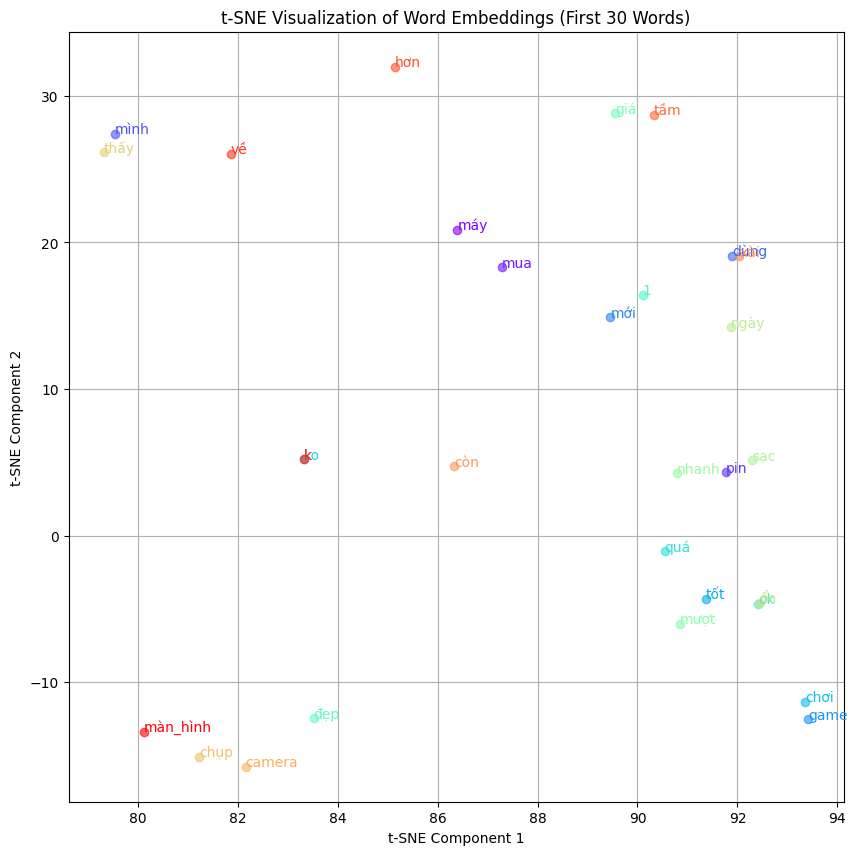

In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Lấy các từ và vector từ mô hình
words = list(model.wv.index_to_key)
word_vectors = model.wv[words]

# Giảm chiều dữ liệu xuống 2 chiều bằng t-SNE
tsne = TSNE(n_components=2, random_state=42)
word_vecs_2d = tsne.fit_transform(word_vectors)

# Trực quan hóa các vectơ từ
plt.figure(figsize=(10, 10))
num_words = 30
# Màu cho mỗi từ
colors = plt.cm.rainbow(np.linspace(0, 1, num_words))

# Vẽ các điểm dữ liệu (từ) với màu khác nhau
for i, word in enumerate(words[:num_words]):  
    plt.scatter(word_vecs_2d[i, 0], word_vecs_2d[i, 1], marker='o', color=colors[i], alpha=0.6)
    plt.annotate(word, xy=(word_vecs_2d[i, 0], word_vecs_2d[i, 1]), fontsize=10, color=colors[i])

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Word Embeddings (First 30 Words)')
plt.grid(True)
plt.show()


## Find similar texts by Cosine measure

In [8]:
question = '''
đầu định mua samsung shop nhân_viên tư_vấn oppo a9 thất_vọng thực dùng oppo màn_hình hiển_thị tối_om máy chơi game giật lang khó_chịu vl sạc lâu k bao_giờ dungg oppo
'''

In [9]:
pemb = PatchEmbedding(word_model=model, stopword_path="../data/data_stopword/vietnamese-stopwords.txt")

question_embeddings = pemb.sentence_embedding(question)
post_embeddings = pemb.post_embedding(input_gensim, length=len(input_gensim))

After tonkenized: 
 đầu định mua samsung shop nhân_viên tư_vấn oppo a9 thất_vọng thực dùng oppo màn_hình hiển_thị tối_om máy chơi game giật lang khó_chịu vl sạc lâu k bao_giờ dungg oppo 



In [10]:
print(len(question_embeddings))
question_embeddings[0]

29


array([ 0.33850354, -0.5414069 ,  0.04056506,  0.20612308,  0.20064078,
        0.08271619, -0.20153826,  0.09227331, -0.09045403,  0.16863899,
        0.37746075, -0.00478844, -0.5131025 , -0.37080348,  0.16660523,
        0.32020962,  0.2865214 , -0.06418881, -0.39243472, -0.00407791,
        0.15773056,  0.25963208, -0.0699392 , -0.36843613, -0.21677776,
        0.07503809, -0.26172382,  0.4074526 ,  0.01349462, -0.19656178,
        0.00618015, -0.05704764, -0.07789717,  0.20568813, -0.1640719 ,
       -0.0743416 ,  0.569507  ,  0.00723204,  0.34661534,  0.34544328,
        0.17401202,  0.21185674, -0.07169229,  0.12664436,  0.19261669,
       -0.05080814,  0.01047387,  0.28447247, -0.34356815,  0.06309415,
        0.06671372,  0.20457254,  0.24020272,  0.49773216, -0.40394056,
        0.2756366 ,  0.3521492 , -0.30947986, -0.09527436,  0.02002743,
        0.15473661, -0.16349573,  0.13916391,  0.3685678 ,  0.3198486 ,
       -0.1945764 , -0.11850794,  0.15241882, -0.17572248, -0.48

In [11]:
mvectorize = MeanVectorizer(word_model=model)

mean_sentence_embedding = mvectorize.mean_vector_embedding(question_embeddings)
mean_post_embedding = mvectorize.mean_posts_embedding(post_embeddings)

In [12]:
print('The len of the mean embedding vector:', len(mean_sentence_embedding))
print('The length of the mean embedding posts:', len(mean_post_embedding))

# Calculate similarity (cosine similarity)
similarity_score = mvectorize.text_cosine_similarity(mean_sentence_embedding, mean_post_embedding)

# Print the similarity score
print(f"Similarity Score: {similarity_score}")

The len of the mean embedding vector: 128
The length of the mean embedding posts: 8898
Similarity Score: [[0.96353334 0.92679524 0.9397303  ... 0.93333304 0.95468235 0.91268516]]


In [13]:
similar_news = mvectorize.find_similarity(similarity_score, news)

np_similarity_scores [[0.96353334 0.92679524 0.9397303  ... 0.93333304 0.95468235 0.91268516]]
Sorted Indices: [   7  541 4033 ... 1731 4895 4074]
Top 5 Indices: [   7  541 4033 1931 4231]


In [14]:
similar_news

,comment,n_star,date_time
7,đầu định mua samsung shop nhân_viên tư_vấn opp...,1,31/05/2020
541,mới mua 2 ngày camera chụp chán thua cả con a5...,1,23/08/2019
4033,máy mua xài dc 2 ngày cảm_nhận máy nhanh tụt p...,2,10/7/2020
1931,fan samsung mơi mua a11 hai ngày quá thất_vọng...,1,24/05/2020
4231,mình sài 3 tháng máy đơ cam nhòe hay lổi bin n...,3,11/1/2020


## Visualize the relationships

* The relationships among words

In [15]:
def words_scatterplot(model, words=None, sample=0):
    if words == None:
        if sample > 0:
            words = np.random.choice(list(model.vocab.keys()), sample)
        else:
            words = [word for word in model.wv.vocab]
        
    word_vectors = np.array([model.wv[w] for w in words])
    
    twodim = PCA().fit_transform(word_vectors)[:,:2]
    
    plt.figure(figsize=(6,6))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
    for word, (x,y) in zip(words, twodim):
        plt.text(x+0.05, y-0.50, word)

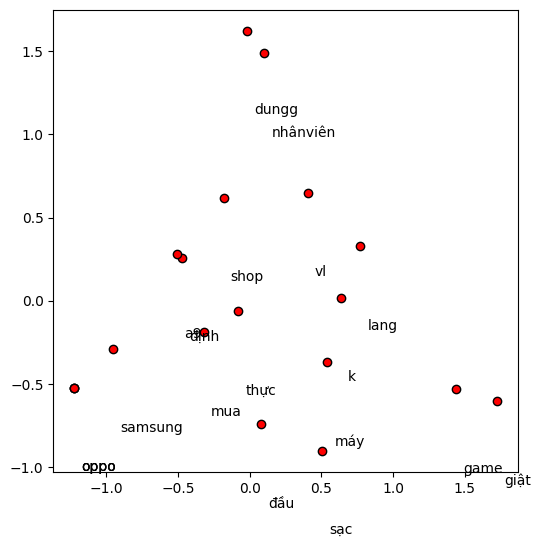

In [24]:
sentence = '''đầu định mua samsung shop nhân_viên tư_vấn oppo a9 thất_vọng thực dùng oppo màn_hình hiển_thị tối_om máy chơi game giật lang khó_chịu vl sạc lâu k bao_giờ dungg oppo'''

sentence = sentence.lower()
sentence = cleandt.remove_punctuation(sentence)
sentence = ViTokenizer.tokenize(sentence)
sentence = cleandt.remove_stopword(sentence, '../data/data_stopword/vietnamese-stopwords-dash.txt')
words = sentence.split()

words_scatterplot(model, words)

* The relationships among documents

In [27]:
temp_embeddings = pemb.post_embedding(input_gensim, 100)
mean_temp_embedding = mvectorize.mean_posts_embedding(temp_embeddings)

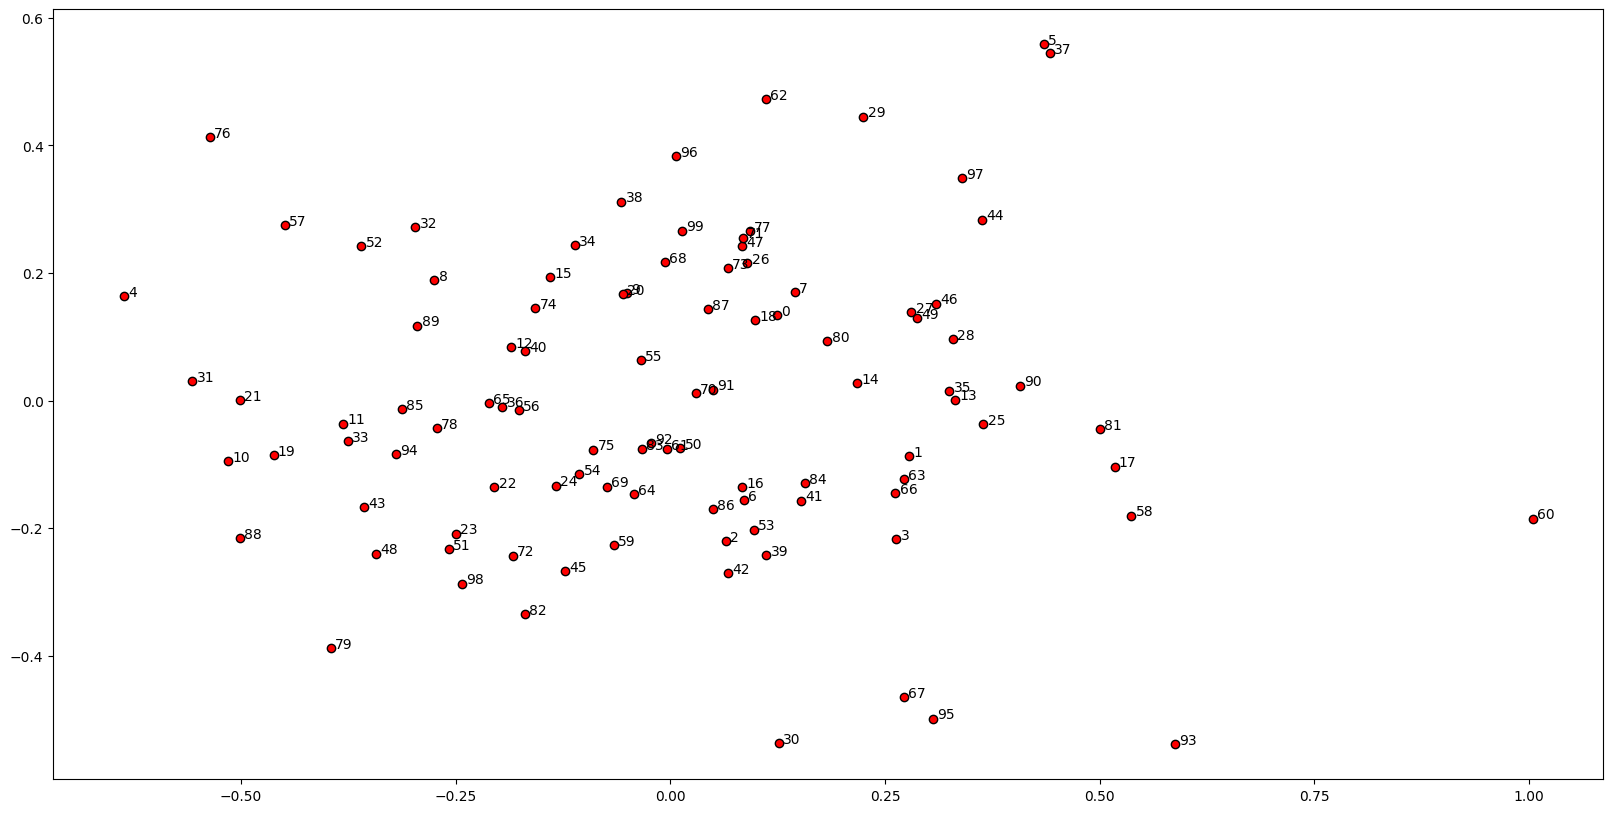

In [28]:
# mean_post_embedding
post_vectors = []
for post_embedding in mean_temp_embedding:
    post_vectors.append(post_embedding.tolist())

twodim = PCA().fit_transform(post_vectors)[:,:2]
index = [i for i,_ in enumerate(mean_temp_embedding)]

plt.figure(figsize=(20,10))
plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
for doc, (x,y) in zip(index, twodim):
    plt.text(x+0.005, y, doc)

In [29]:
# Giả sử input_gensim là tập dữ liệu đã được chuẩn bị từ trước
text_embeddings = pemb.post_embedding(input_gensim)

print(f"Number of text embeddings: {len(text_embeddings)}")
print(f"Length of each embedding: {len(text_embeddings[0])}")

# Tính toán mean embedding
mean_text_embeddings = mvectorize.flatten_mean_embedding(text_embeddings)
print(f"Number of mean text embeddings: {len(mean_text_embeddings)}")

# Đệm thêm 0 để đủ độ dài trong từng văn bản
max_length = max([len(i) for i in mean_text_embeddings])
mean_text_embeddings_padding = np.array(sequence.pad_sequences(mean_text_embeddings, maxlen=max_length, padding='pre', dtype='float32'))

print("The shape of padding sequences array:", mean_text_embeddings_padding.shape)
print(mean_text_embeddings_padding[:5])


Number of text embeddings: 8898
Length of each embedding: 14


100%|██████████| 8898/8898 [00:00<00:00, 16797.91it/s]

Number of mean text embeddings: 8898
The shape of padding sequences array: (8898, 129)
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00

c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\clus

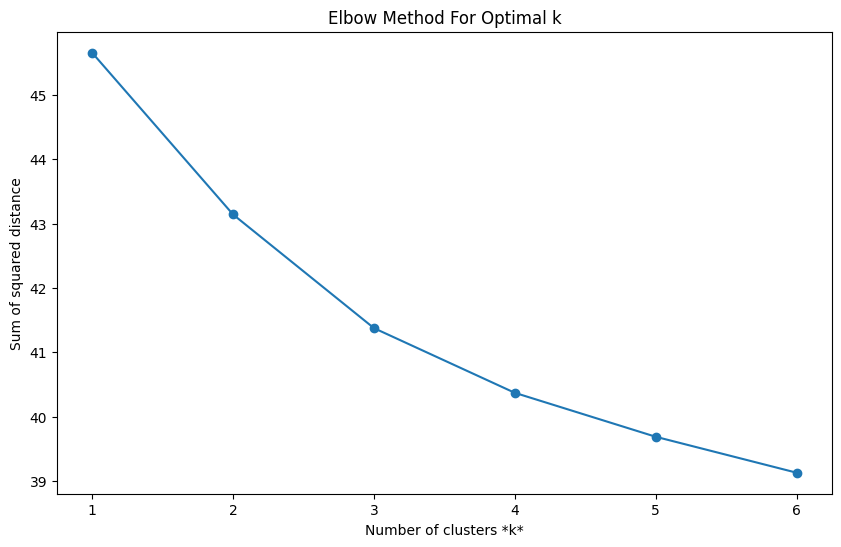

In [43]:
# Tính toán SSE cho các giá trị k khác nhau
sse = []
list_k = list(range(1, 7))

for k in list_k:
    km = KMeans(n_clusters=k)
    km.fit(mean_text_embeddings_padding)
    sse.append(km.inertia_)

# Vẽ đồ thị SSE theo số lượng cụm
plt.figure(figsize=(10, 6))
plt.plot(list_k, sse, '-o')
plt.xlabel(r'Number of clusters *k*')
plt.ylabel('Sum of squared distance')
plt.title('Elbow Method For Optimal k')
plt.show()


In [44]:
# Giả sử số lượng cụm tối ưu là 3 từ biểu đồ Elbow
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, verbose=1).fit(mean_text_embeddings_padding)
text_clustering = kmeans.predict(mean_text_embeddings_padding)


c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Initialization complete
Iteration 0, inertia 58.50647735595703.
Iteration 1, inertia 43.405906677246094.
Iteration 2, inertia 42.268184661865234.
Iteration 3, inertia 41.809024810791016.
Iteration 4, inertia 41.61927032470703.
Iteration 5, inertia 41.51542663574219.
Iteration 6, inertia 41.46127700805664.
Iteration 7, inertia 41.43440628051758.
Iteration 8, inertia 41.418487548828125.
Iteration 9, inertia 41.40573501586914.
Iteration 10, inertia 41.39585494995117.
Iteration 11, inertia 41.389835357666016.
Iteration 12, inertia 41.38599395751953.
Iteration 13, inertia 41.38361740112305.
Iteration 14, inertia 41.381439208984375.
Iteration 15, inertia 41.37986755371094.
Iteration 16, inertia 41.378700256347656.
Iteration 17, inertia 41.37805938720703.
Iteration 18, inertia 41.377437591552734.
Iteration 19, inertia 41.37703323364258.
Iteration 20, inertia 41.37685775756836.
Iteration 21, inertia 41.37679672241211.
Iteration 22, inertia 41.37678527832031.
Iteration 23, inertia 41.3767471313

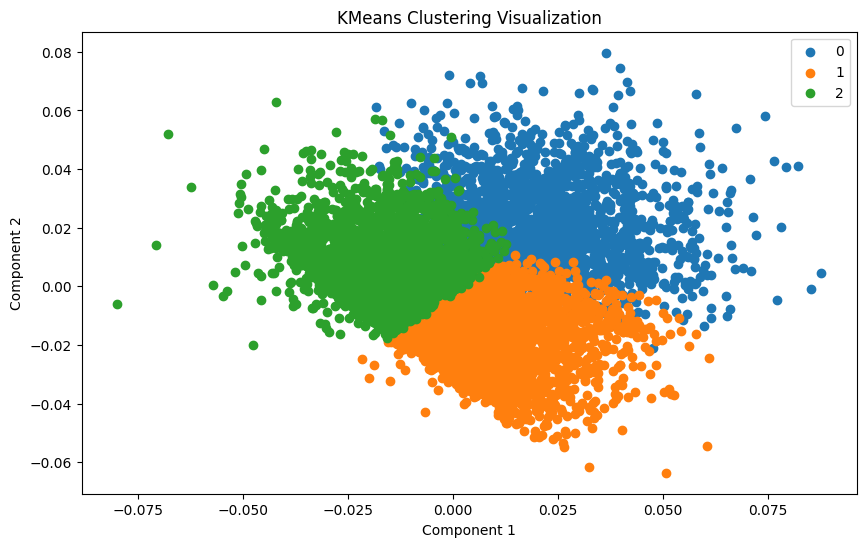

In [45]:
# Giảm chiều dữ liệu xuống 2D để trực quan hóa
embedding_2d = PCA(n_components=2).fit_transform(mean_text_embeddings_padding)
temp = np.append(embedding_2d, text_clustering.reshape((len(text_clustering), 1)), axis=1)
df = pd.DataFrame(temp, columns=['Component 1', 'Component 2', 'Cluster'])

# Trực quan hóa kết quả phân cụm
u_labels = np.unique(text_clustering)
plt.figure(figsize=(10, 6))
for i in u_labels:
    plt.scatter(df[df['Cluster'] == i]['Component 1'], df[df['Cluster'] == i]['Component 2'], label=i)
plt.legend()
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('KMeans Clustering Visualization')
plt.show()


In [46]:
# Gắn nhãn cho dữ liệu gốc
clustered_news = news.copy()
clustered_news['Cluster'] = text_clustering

# Đặt tên các cụm theo thứ tự: Positive, Negative, Neutral
cluster_names = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}
clustered_news['Cluster Name'] = clustered_news['Cluster'].map(cluster_names)

# Hiển thị một số dòng dữ liệu với nhãn cụm và tên cụm
clustered_news.head(10)


,comment,n_star,date_time,Cluster,Cluster Name
0,pin kém còn miễn chê mua 832019 tình_trạng pin...,5,14/09/2019,2,Neutral
1,sao gọi điện_thoại màn_hình chấm nhỏ nháy gần ...,3,17/08/2020,1,Negative
2,mọi người cập_nhật phần_mềm nó bớt tốn pin mìn...,3,29/02/2020,2,Neutral
3,mới mua sài 1 tháng thấy pin trâu sài bao mượt...,5,4/6/2020,0,Positive
4,xài tốt mượt pin trâu bạn độ sáng đủ nhân_viên...,5,20/06/2019,1,Negative
5,hôm ngày 2362020 e thế_giới di_động mua dthoai...,2,23/06/2020,2,Neutral
6,sao điện_thoại mới sạc nó nóng máy quá trời t_...,2,23/12/2019,0,Positive
7,đầu định mua samsung shop nhân_viên tư_vấn opp...,1,31/05/2020,2,Neutral
8,mọi thứ ngon trong tầm giá lần đầu xài xiaomi ...,5,30/05/2020,1,Negative
9,đi thoại mượt chơi game ngon âm báo_thức bật m...,4,7/6/2019,2,Neutral


In [47]:
# Drop cột Cluster
clustered_news = clustered_news.drop(columns=['Cluster'])

# Đổi tên cột Cluster Name thành label
clustered_news = clustered_news.rename(columns={'Cluster Name': 'label'})

# Gán dataframe mới cho biến trainprocess_kmeans
trainprocess_kmeans = clustered_news.copy()

# Hiển thị một số dòng dữ liệu của dataframe mới
trainprocess_kmeans.head()
 

,comment,n_star,date_time,label
0,pin kém còn miễn chê mua 832019 tình_trạng pin...,5,14/09/2019,Neutral
1,sao gọi điện_thoại màn_hình chấm nhỏ nháy gần ...,3,17/08/2020,Negative
2,mọi người cập_nhật phần_mềm nó bớt tốn pin mìn...,3,29/02/2020,Neutral
3,mới mua sài 1 tháng thấy pin trâu sài bao mượt...,5,4/6/2020,Positive
4,xài tốt mượt pin trâu bạn độ sáng đủ nhân_viên...,5,20/06/2019,Negative


In [48]:
# Tính chỉ số Silhouette
silhouette_avg = silhouette_score(mean_text_embeddings_padding, text_clustering)
print(f"Silhouette Score for KMeans: {silhouette_avg}")


Silhouette Score for KMeans: 0.0322239026427269


In [49]:
# DBSCAN
dbscan = DBSCAN(eps=3, min_samples=5)
labels_dbscan = dbscan.fit_predict(mean_text_embeddings_padding)

# Kiểm tra số lượng cụm và chỉ số Silhouette cho DBSCAN
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
if n_clusters_dbscan > 1:
    silhouette_dbscan = silhouette_score(mean_text_embeddings_padding, labels_dbscan)
else:
    silhouette_dbscan = -1  # Không thể tính chỉ số Silhouette khi chỉ có 1 cụm
print(f"Số lượng cụm từ DBSCAN: {n_clusters_dbscan}")
print(f"Silhouette Score cho DBSCAN: {silhouette_dbscan}")

Số lượng cụm từ DBSCAN: 1
Silhouette Score cho DBSCAN: -1


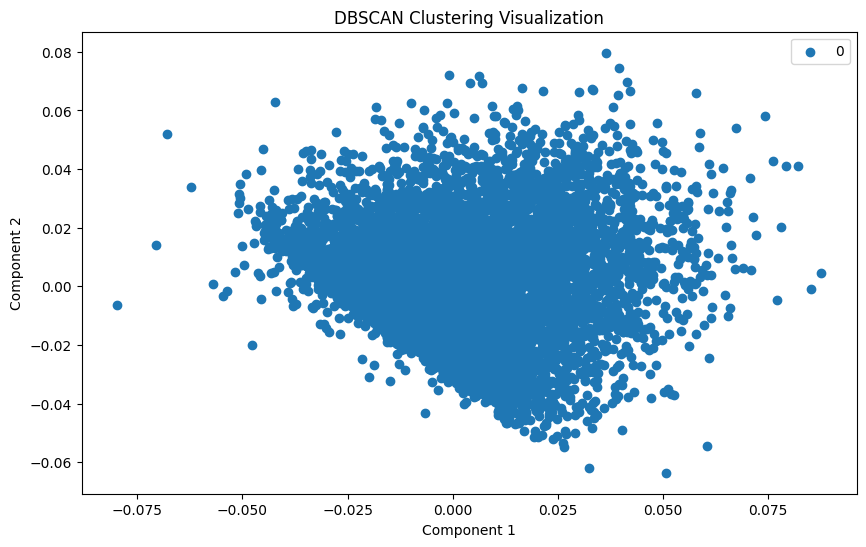

In [50]:
# Trực quan hóa kết quả phân cụm của DBSCAN
embedding_2d_dbscan = PCA(n_components=2).fit_transform(mean_text_embeddings_padding)
temp_dbscan = np.append(embedding_2d_dbscan, labels_dbscan.reshape((len(labels_dbscan), 1)), axis=1)
df_dbscan = pd.DataFrame(temp_dbscan, columns=['Component 1', 'Component 2', 'Cluster'])

plt.figure(figsize=(10, 6))
u_labels_dbscan = np.unique(labels_dbscan)
for i in u_labels_dbscan:
    if i == -1:
        # Plot noise points in black
        plt.scatter(df_dbscan[df_dbscan['Cluster'] == i]['Component 1'], df_dbscan[df_dbscan['Cluster'] == i]['Component 2'], label='Noise', c='black')
    else:
        plt.scatter(df_dbscan[df_dbscan['Cluster'] == i]['Component 1'], df_dbscan[df_dbscan['Cluster'] == i]['Component 2'], label=i)
plt.legend()
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('DBSCAN Clustering Visualization')
plt.show()

Silhouette Score cho Agglomerative Clustering: 0.004047233611345291


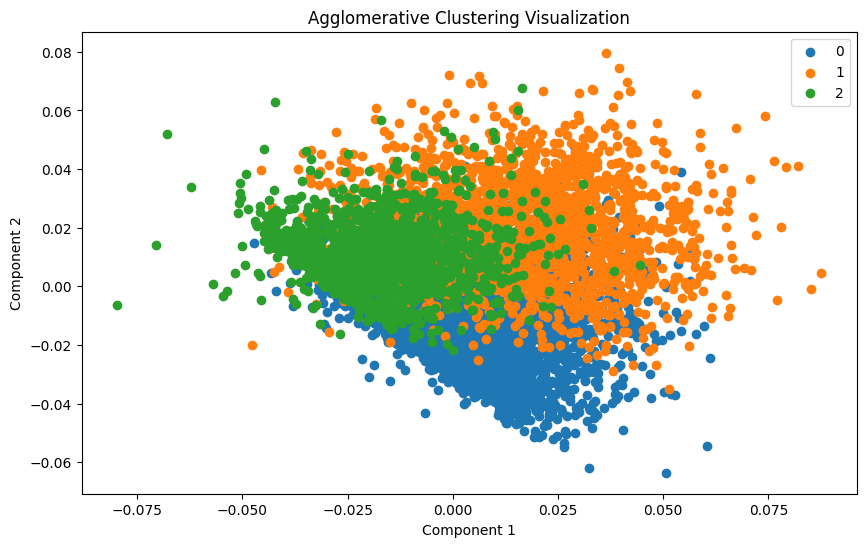

In [51]:
# Agglomerative Clustering
agglomerative = AgglomerativeClustering(n_clusters=3)
labels_agglomerative = agglomerative.fit_predict(mean_text_embeddings_padding)

# Kiểm tra số lượng cụm và chỉ số Silhouette cho Agglomerative Clustering
silhouette_agglomerative = silhouette_score(mean_text_embeddings_padding, labels_agglomerative)
print(f"Silhouette Score cho Agglomerative Clustering: {silhouette_agglomerative}")

# Trực quan hóa kết quả phân cụm của Agglomerative Clustering
embedding_2d_agg = PCA(n_components=2).fit_transform(mean_text_embeddings_padding)
temp_agg = np.append(embedding_2d_agg, labels_agglomerative.reshape((len(labels_agglomerative), 1)), axis=1)
df_agg = pd.DataFrame(temp_agg, columns=['Component 1', 'Component 2', 'Cluster'])

plt.figure(figsize=(10, 6))
u_labels_agg = np.unique(labels_agglomerative)
for i in u_labels_agg:
    plt.scatter(df_agg[df_agg['Cluster'] == i]['Component 1'], df_agg[df_agg['Cluster'] == i]['Component 2'], label=i)
plt.legend()
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Agglomerative Clustering Visualization')
plt.show()
